# Ni-W electrodeposition: multi-objective Bayesian optimization with Ax

One round of a human-in-the-loop optimization campaign:

1. Load every experiment so far from `data/experiments.csv`.
2. Rebuild the Ax experiment from that table.
3. Look at the measured Pareto front and the progress of the campaign.
4. Check how well the surrogate model predicts each objective, and what it has learned.
5. Ask Ax for the next batch of experiments and add it to the table.

After the batch has been run in the lab, enter the measured values in the CSV and run the notebook again.

Both objectives are maximized: `overpotential` is negative, so closer to zero is better, and `overpotential_slope` measures stability over cycling, where ≥ 0 means no degradation. The search space and objective thresholds live in `src/niw_bo/config.py`.

**About the data.** The first 10 experiments are lab measurements. Batches 1 and 2 are points Ax actually suggested, completed with illustrative values (not measurements) to demonstrate the loop; the `source` column marks them. By default everything below uses the lab measurements only. Set `INCLUDE_ILLUSTRATIVE = True` to run the full demo with all 16 rows, where the illustrative points are drawn hollow.

Ax computes everything (model fits, hypervolume, cross-validation, sensitivity, predictions); the figures are drawn with matplotlib from `src/niw_bo/plotting.py`. Ax's own interactive analysis cards are optional, at the end.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from ax.utils.common.logger import set_stderr_log_level

from niw_bo import (
    attach_experiments,
    build_client,
    lab_only,
    load_experiments,
    plot_contour,
    plot_cross_validation,
    plot_hypervolume,
    plot_observed_front,
    plot_sensitivity,
    plot_slices,
    suggest_next_batch,
)

set_stderr_log_level(logging.WARNING)  # hide Ax's per-trial INFO messages

DATA = Path("data/experiments.csv")
INCLUDE_ILLUSTRATIVE = False  # True also uses the illustrative rows (demo of the loop)
SEED = 0  # same table + same seed -> same suggestions; None for fresh ones
APPEND_TO_CSV = False  # True writes the suggested batch into the table
SHOW_AX_CARDS = False  # True also shows Ax's interactive analysis cards (section 7)

## 1. Experiments so far

Batch 0 is the initial design chosen by hand; later batches were suggested by Ax. Rows with empty objectives are experiments that are queued but not yet measured. `table` is the whole file; `df` is what the analyses use.

In [2]:
table = load_experiments(DATA)
df = table if INCLUDE_ILLUSTRATIVE else lab_only(table)
table

,batch,tungstate_concentration,current_density,deposition_time,pH,overpotential,overpotential_slope,source
0,0,0.050000,10,500,5.0,-358.0,0.000150,lab
1,0,0.050000,50,300,6.0,-319.0,0.000066,lab
2,0,0.100000,10,300,7.0,-377.0,0.000100,lab
3,0,0.100000,10,600,8.0,-319.0,-0.000518,lab
4,0,0.100000,50,600,7.5,-286.0,0.000080,lab
5,0,0.100000,100,600,10.0,-312.0,0.000029,lab
6,0,0.100000,50,400,6.5,-309.0,-0.000057,lab
7,0,0.100000,30,600,8.5,-290.0,0.001656,lab
8,0,0.150000,10,600,9.5,-329.0,0.000131,lab
9,0,0.150000,50,300,9.5,-305.0,-0.000064,lab


## 2. Rebuild the Ax experiment

Each row becomes a trial. Measured rows are completed; unmeasured rows stay `RUNNING`, so Ax treats them as pending and does not propose the same point again.

Because the lab data already serves as the initial design, the generation strategy goes straight to Bayesian optimization: one Gaussian process per objective and the qLogNEHVI acquisition function, with no quasi-random warm-up points.

In [3]:
client = build_client(seed=SEED)
attach_experiments(client, df)
client.summarize()

,trial_index,arm_name,trial_status,overpotential,overpotential_slope,tungstate_concentration,current_density,deposition_time,pH
0,0,0_0,COMPLETED,-358.0,0.000150,0.05,10,500,5.0
1,1,1_0,COMPLETED,-319.0,0.000066,0.05,50,300,6.0
2,2,2_0,COMPLETED,-377.0,0.000100,0.10,10,300,7.0
3,3,3_0,COMPLETED,-319.0,-0.000518,0.10,10,600,8.0
4,4,4_0,COMPLETED,-286.0,0.000080,0.10,50,600,7.5
5,5,5_0,COMPLETED,-312.0,0.000029,0.10,100,600,10.0
6,6,6_0,COMPLETED,-309.0,-0.000057,0.10,50,400,6.5
7,7,7_0,COMPLETED,-290.0,0.001656,0.10,30,600,8.5
8,8,8_0,COMPLETED,-329.0,0.000131,0.15,10,600,9.5
9,9,9_0,COMPLETED,-305.0,-0.000064,0.15,50,300,9.5


## 3. Measured Pareto front and progress

Circled points are non-dominated: no other experiment is at least as good on both objectives and better on one. The dashed lines are the objective thresholds; only the region above and to the right of both counts towards the hypervolume.

With the illustrative rows included, the y axis switches to linear within ±10⁻³ and logarithmic beyond, because one illustrative slope value (−0.02) is an order of magnitude larger than the rest.

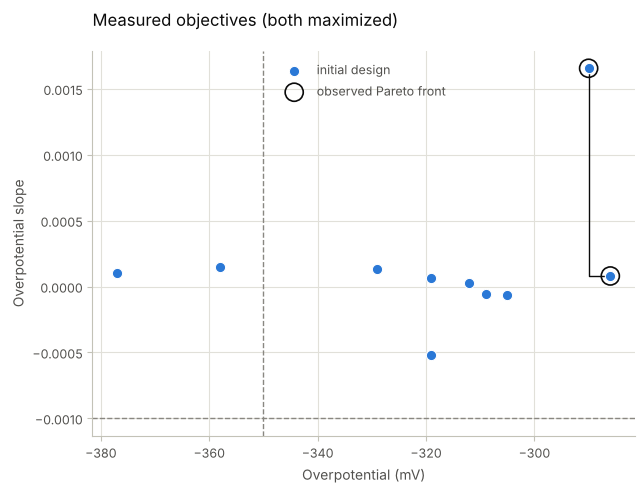

In [4]:
plot_observed_front(df, symlog_y=1e-3 if INCLUDE_ILLUSTRATIVE else None);

The hypervolume is the area dominated by the measured Pareto front, relative to the thresholds. It only rises when a trial adds a new non-dominated point; flat stretches mean the trials in between did not.

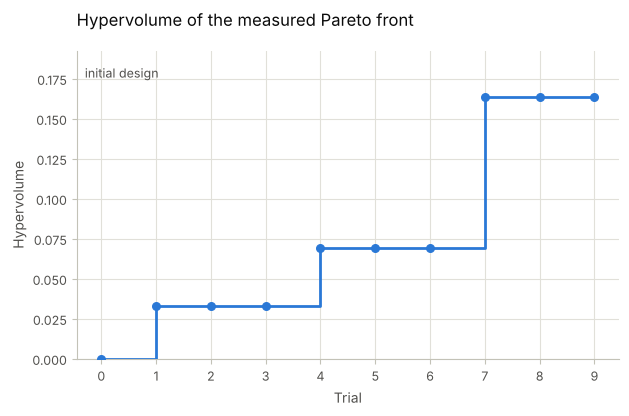

In [5]:
plot_hypervolume(client, df);

## 4. How well does the model predict?

Leave-one-out cross-validation: each trial is predicted by a model fitted to all the other trials. Points close to the diagonal mean the model is useful for that objective; predictions stuck near the mean whatever the measured value mean it has not found a pattern. When an objective is poorly predicted, the suggestions for it are closer to exploration than exploitation; check for noisy measurements or outliers.

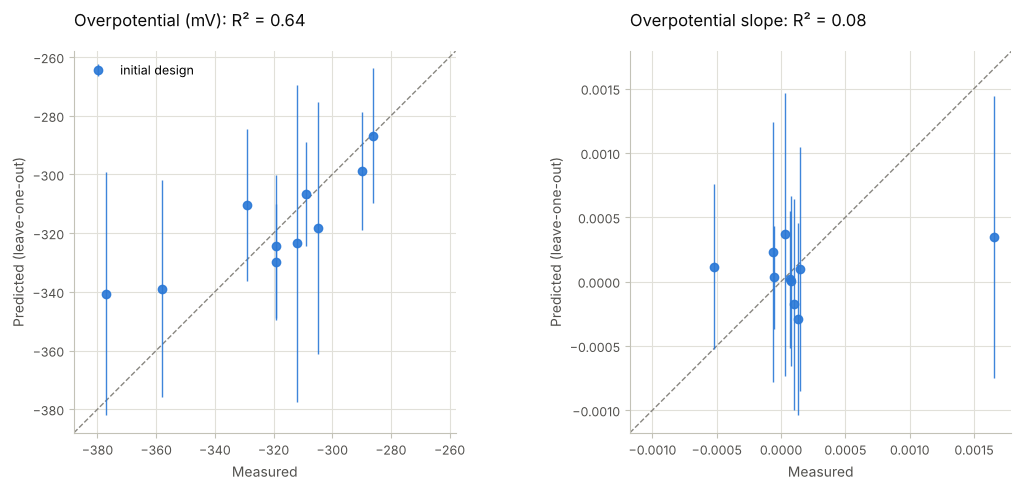

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_cross_validation(client, df, "overpotential", ax=axes[0])
plot_cross_validation(client, df, "overpotential_slope", ax=axes[1],
                      symlog=1e-3 if INCLUDE_ILLUSTRATIVE else None)
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()

## 5. What has the model learned?

These figures describe the model, not the measurements, so they are only as trustworthy as the cross-validation above. They are shown for the overpotential; with the slope model's current fit they would mostly show noise. Change `"overpotential"` to `"overpotential_slope"` to see them anyway.

**Sensitivity**: total-order Sobol indices, the share of the model's predicted variation that involves each parameter, including through interactions.

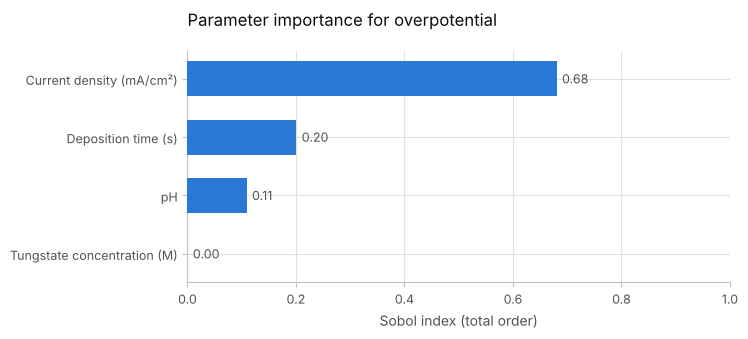

In [7]:
plot_sensitivity(client, "overpotential");

**Contour and slices**: the model's predicted overpotential, with the other parameters fixed at the measured trial with the best overpotential. The slices show one parameter at a time with a 95% band; ticks along the bottom mark the values tested so far.

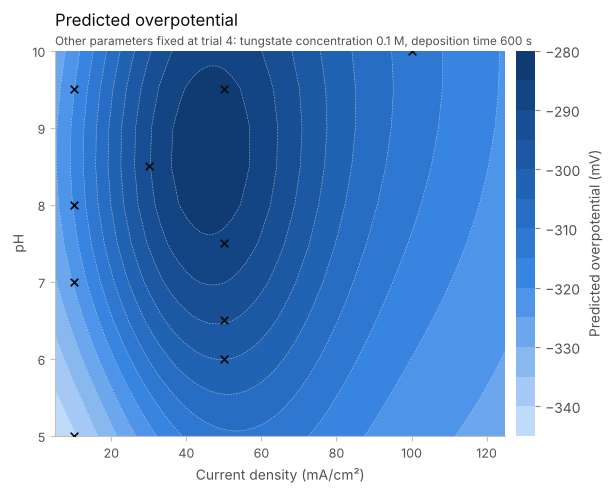

In [8]:
plot_contour(client, df, "overpotential", "current_density", "pH");

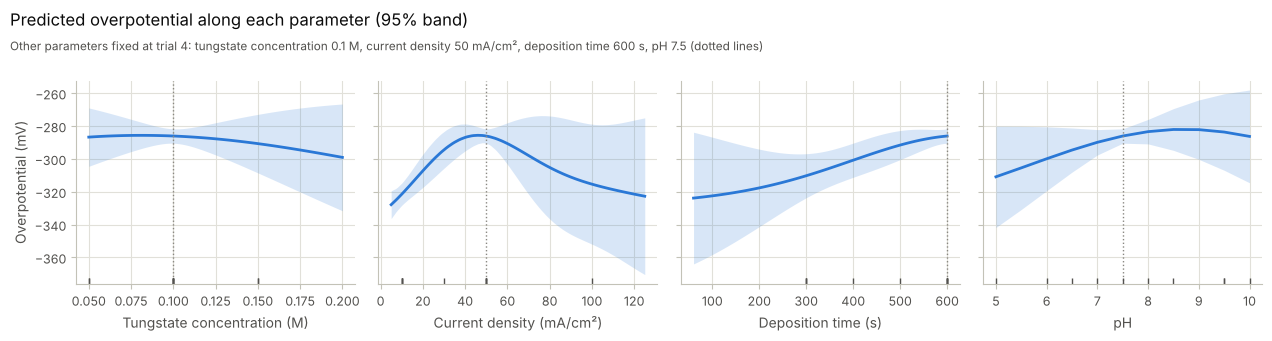

In [9]:
plot_slices(client, df, "overpotential");

### Model-based Pareto front

With `use_model_predictions=True`, the front is computed from the model's predicted means, which smooths out measurement noise; `False` uses the raw measurements, as in the plot in section 3. Values are predicted mean ± standard deviation. Note that with model predictions Ax returns the predicted *variance* as the second element of each pair, not the standard error.

In [10]:
frontier = client.get_pareto_frontier(use_model_predictions=True)
pd.DataFrame(
    [
        {
            "trial_index": trial_index,
            **parameters,
            **{name: f"{mean:.4g} ± {var ** 0.5:.2g}" for name, (mean, var) in metrics.items()},
        }
        for parameters, metrics, trial_index, _ in frontier
    ]
)

,trial_index,tungstate_concentration,current_density,deposition_time,pH,overpotential,overpotential_slope
0,7,0.1,30,600,8.5,-290.4 ± 2.2,0.001647 ± 4.6e-05
1,4,0.1,50,600,7.5,-286 ± 2.2,7.863e-05 ± 4.5e-05


## 6. Next batch

`get_next_trials` builds the batch one point at a time, treating points already proposed and experiments not yet measured as pending, so the batch spreads out instead of clustering. Suggested values come at full precision; before entering results, change them in the CSV to what was actually prepared in the lab.

In [11]:
next_batch = suggest_next_batch(client, table)  # numbered after the last batch in the file
next_batch

,batch,tungstate_concentration,current_density,deposition_time,pH,overpotential,overpotential_slope,source
0,3,0.050000,34,600,9.0,NaN,NaN,lab
1,3,0.068569,46,600,9.5,NaN,NaN,lab
2,3,0.142484,34,596,8.0,NaN,NaN,lab


In [12]:
if APPEND_TO_CSV:
    pd.concat([table, next_batch], ignore_index=True).to_csv(DATA, index=False)

Then run the batch, fill in the empty objective cells in `data/experiments.csv`, and run the notebook from the top. New rows are marked `source = lab`; the illustrative rows can be deleted once real measurements take their place. `python scripts/make_figures.py` refreshes the figures in the README.

The CSV is the record of the campaign. `client.save_to_json_file()` and `Client.load_from_json_file()` can still snapshot the full Ax state, but those files are tied to the Ax version that wrote them.

## 7. Ax's interactive analyses (optional)

`client.compute_analyses()` picks the analyses that suit the current state of the experiment and shows them as interactive Plotly cards, including some not drawn above (arm effects, health checks). They render in Jupyter but not on GitHub, and the generation-strategy diagram among them needs the [Graphviz](https://graphviz.org/download/) program installed. Set `SHOW_AX_CARDS = True` at the top to run it.

In [13]:
if SHOW_AX_CARDS:
    cards = client.compute_analyses()